<a href="https://colab.research.google.com/github/benishshrestha66/Projects/blob/main/Predictive%20AI%20model%20for%20Cholera.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report, mean_absolute_error

import matplotlib.pyplot as plt

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Choleraa.xlsx to Choleraa (3).xlsx


In [ ]:

df = pd.read_excel("Choleraa.xlsx")
df.head()

,EpidNo,state,epiweek,season,setting,healthfac_type,geo,sex,age,age_cat,...,cult_cat,cult_bin,outcome,heathfac_presn,sample_tak,tested,sec,flood,flood_cat,lga_new
0,NIE-KNS-GWL-18-046,Kano,W01,dry season,urban,NaN,north-west,female,80.0,15 years & above,...,NaN,NaN,alive,NaN,no,no,No insurgency,reported flooding i 2018,mild flooding in 2018,Gwale
1,NIE-KNS-UGG-18-061,Kano,W01,dry season,rural,NaN,north-west,female,25.0,15 years & above,...,NaN,NaN,alive,NaN,no,no,No insurgency,reported flooding i 2018,mild flooding in 2018,Ungogo
2,NIE-KNS-UGG-18-065,Kano,W01,dry season,rural,NaN,north-west,male,15.0,15 years & above,...,NaN,NaN,alive,NaN,no,no,No insurgency,reported flooding i 2018,mild flooding in 2018,Ungogo
3,NIE-KNS-UGG-18-063,Kano,W01,dry season,rural,NaN,north-west,male,12.0,11-14 yrs,...,NaN,NaN,alive,NaN,no,no,No insurgency,reported flooding i 2018,mild flooding in 2018,Ungogo
4,NIE-KNS-FGE-18-039,Kano,W01,dry season,urban,NaN,north-west,male,15.0,15 years & above,...,NaN,NaN,dead,NaN,no,no,No insurgency,reported flooding i 2018,mild flooding in 2018,Fagge


In [ ]:
df.columns = df.columns.str.lower().str.replace(" ", "_")

df = df.dropna()

df.head()

,epidno,state,epiweek,season,setting,healthfac_type,geo,sex,age,age_cat,...,cult_cat,cult_bin,outcome,heathfac_presn,sample_tak,tested,sec,flood,flood_cat,lga_new
15064,NIE-PLS-JJN-18-260,Plateau,W25,rainy season,urban,Primary,north-central,male,73.0,15 years & above,...,positive,positive,alive,yes,yes,yes,No insurgency,reported flooding i 2018,mild flooding in 2018,Jos North
15609,NIE-PLS-BUU-18-001,Plateau,W25,rainy season,urban,Tertiary,north-central,female,37.0,15 years & above,...,positive,positive,alive,yes,yes,yes,No insurgency,reported flooding i 2018,mild flooding in 2018,Jos North


In [ ]:
print(df.columns)

Index(['epidno', 'state', 'epiweek', 'season', 'setting', 'healthfac_type',
       'geo', 'sex', 'age', 'age_cat', 'age_cat2', 'rdt_cat', 'rdt_bin',
       'cult_cat', 'cult_bin', 'outcome', 'heathfac_presn', 'sample_tak',
       'tested', 'sec', 'flood', 'flood_cat', 'lga_new'],
      dtype='object')


In [ ]:
df = df.sort_values(["state", "epiweek"])

In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
epidno,0
state,0
epiweek,0
season,0
setting,0
healthfac_type,0
geo,0
sex,0
age,0
age_cat,0


In [ ]:
df = pd.read_excel("Choleraa.xlsx", na_values=["NA", "N/A", "null", "", " ", -1, 999])

In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
cult_bin,43863
cult_cat,43859
rdt_bin,42903
rdt_cat,42900
healthfac_type,28298
sample_tak,21260
heathfac_presn,17676
EpidNo,10446
age,1361
age_cat,1361


In [ ]:
df = df.drop(columns=["cult_bin", "cult_cat", "rdt_bin", "rdt_cat"], errors="ignore")

In [ ]:
df["age"] = df["age"].fillna(df.groupby("state")["age"].transform("median"))

In [ ]:
cat_cols = ["setting", "healthfac_type", "sample_tak", "heathfac_presn"]

for col in cat_cols:
  if col in df.columns:
    df[col] = df[col].fillna("Unknown")

In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
cult_bin,43863
cult_cat,43859
rdt_bin,42903
rdt_cat,42900
EpidNo,10446
age_cat2,1361
age_cat,1361
sex,1
healthfac_type,0
geo,0


In [ ]:
df["sex"] = df["sex"].fillna(df["sex"].mode()[0])

In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
cult_bin,43863
cult_cat,43859
rdt_bin,42903
rdt_cat,42900
EpidNo,10446
age_cat2,1361
age_cat,1361
geo,0
healthfac_type,0
setting,0


In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
cult_bin,43863
cult_cat,43859
rdt_bin,42903
rdt_cat,42900
EpidNo,10446
age_cat2,1361
age_cat,1361
geo,0
healthfac_type,0
setting,0


In [ ]:
df = df.drop(columns=["EpidNo"])

In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
cult_bin,43863
cult_cat,43859
rdt_bin,42903
rdt_cat,42900
age_cat2,1361
age_cat,1361
geo,0
healthfac_type,0
setting,0
season,0


In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost joblib -q


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    recall_score, precision_score, f1_score
)
import xgboost as xgb
import joblib
import warnings
warnings.filterwarnings('ignore')


# imbalanced-learn: the key library for this problem
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline

import joblib



In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
cult_bin,43863
cult_cat,43859
rdt_bin,42903
rdt_cat,42900
age_cat2,1361
age_cat,1361
geo,0
healthfac_type,0
setting,0
season,0


In [ ]:
df['epiweek'] = df['epiweek'].str.replace('W', '').astype(int)

In [ ]:
df.tail(5)

,state,epiweek,season,setting,healthfac_type,geo,sex,age,age_cat,age_cat2,...,cult_cat,cult_bin,outcome,heathfac_presn,sample_tak,tested,sec,flood,flood_cat,lga_new
43991,Borno,47,dry season,urban,Unknown,north-east,female,1.0,Less than 2 yrs,Less than 5 years,...,NaN,NaN,alive,no,no,no,insurgency,no flooding in 2018,no flooding in 2018,MMC
43992,Borno,47,dry season,urban,Unknown,north-east,female,37.0,15 years & above,>=18 years,...,NaN,NaN,alive,yes,no,no,insurgency,no flooding in 2018,no flooding in 2018,MMC
43993,Borno,47,dry season,urban,Unknown,north-east,female,24.0,15 years & above,>=18 years,...,NaN,NaN,alive,yes,no,no,insurgency,no flooding in 2018,no flooding in 2018,MMC
43994,Borno,47,dry season,urban,Unknown,north-east,female,90.0,15 years & above,>=18 years,...,NaN,NaN,alive,no,no,no,insurgency,no flooding in 2018,no flooding in 2018,MMC
43995,Borno,47,dry season,urban,Unknown,north-east,male,13.0,11-14 yrs,5-17 years,...,NaN,NaN,alive,yes,no,no,insurgency,no flooding in 2018,no flooding in 2018,MMC


In [ ]:

FEATURES =['state',          # Categorical — Nigerian state
    'epiweek',        # Numeric    — Epidemiological week
    'season',         # Categorical — Season
    'setting',        # Categorical — Urban/Rural
    'healthfac_type', # Categorical — Type of health facility
    'geo',            # Categorical — Geographic zone
    'sex',            # Categorical — Patient sex
    'age',            # Numeric    — Patient age
    'heathfac_presn', # Binary     — Health facility presentation
    'sample_tak',     # Binary     — Sample taken
    'tested',         # Binary     — Patient tested
    'sec',            # Binary     — Secondary care access
    'flood',          # Binary     — Flood exposure
    'flood_cat',      # Categorical — Flood category
    'lga_new',        # Categorical — Local Government Area
]

TARGET = 'outcome'

X = df[FEATURES].copy()
y = df[TARGET].copy()

print(f'Features: {len(FEATURES)}')
print(f'Target:   {TARGET}')
print(f'Samples:  {len(X)}')

encodertarget = LabelEncoder()
y_encod = encodertarget.fit_transform(y.astype(str))
print(f'\nTarget encoding: {dict(zip(encodertarget.classes_, encodertarget.transform(encodertarget.classes_)))}')

Labes = {}
for hari in X.select_dtypes(include='object').columns:
    ram = LabelEncoder()
    X[hari] = ram.fit_transform(X[hari].astype(str))
    Labes[hari] = ram
    print(f'  Encoded: {col}')

X = X.apply(pd.to_numeric, errors='coerce')

print(f'Preprocessing complete. Shape: {X.shape}')

death_rate = (y_encod == 1).mean() * 100
print(f'\nClass distribution:')
print(pd.Series(y_encod).value_counts())
print(f'Death rate: {death_rate:.2f}%')
print(f'Imbalance ratio: 1 death for every {(y_encod==0).sum()/(y_encod==1).sum():.0f} survivors')

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encod, test_size=0.2, random_state=42, stratify=y_encod
)
print(f'\nTrain deaths: {(y_train==1).sum()}  &  Test deaths: {(y_test==1).sum()}')

Features: 15
Target:   outcome
Samples:  43996

Target encoding: {'alive': np.int64(0), 'dead': np.int64(1)}
  Encoded: heathfac_presn
  Encoded: heathfac_presn
  Encoded: heathfac_presn
  Encoded: heathfac_presn
  Encoded: heathfac_presn
  Encoded: heathfac_presn
  Encoded: heathfac_presn
  Encoded: heathfac_presn
  Encoded: heathfac_presn
  Encoded: heathfac_presn
  Encoded: heathfac_presn
  Encoded: heathfac_presn
  Encoded: heathfac_presn
Preprocessing complete. Shape: (43996, 15)

Class distribution:
0    43160
1      836
Name: count, dtype: int64
Death rate: 1.90%
Imbalance ratio: 1 death for every 52 survivors

Train deaths: 669  &  Test deaths: 167


In [ ]:
# Train a NORMAL model with no imbalance handling, to show the problem
baseline_model = xgb.XGBClassifier(n_estimators=100, random_state=42,
                                     eval_metric='logloss', verbosity=0)
baseline_model.fit(X_train, y_train)
baseline_preds = baseline_model.predict(X_test)

acc    = (baseline_preds == y_test).mean()
recall = recall_score(y_test, baseline_preds)

print(f'❌ BASELINE MODEL (no imbalance handling)')
print(f'   Accuracy : {acc:.4f}  ← looks great!')
print(f'   Recall (death class): {recall:.4f}  ← terrible! Misses almost every death.')
print(f'\n   Deaths in test set: {(y_test==1).sum()}')
print(f'   Deaths correctly caught: {((baseline_preds==1) & (y_test==1)).sum()}')
print(f'\n   This is the classic imbalanced-data trap: the model just predicts')
print(f'   "Alive" almost every time because it minimizes overall error,')
print(f'   not because it understands death risk.')

❌ BASELINE MODEL (no imbalance handling)
   Accuracy : 0.9805  ← looks great!
   Recall (death class): 0.0120  ← terrible! Misses almost every death.

   Deaths in test set: 167
   Deaths correctly caught: 2

   This is the classic imbalanced-data trap: the model just predicts
   "Alive" almost every time because it minimizes overall error,
   not because it understands death risk.


In [ ]:
n_alive = (y_train == 0).sum()
n_death = (y_train == 1).sum()
scale_pos_weight = n_alive / n_death

print(f'scale_pos_weight = {scale_pos_weight:.1f}')
print(f'(As per this ratio, for XGBoost a missed death is {scale_pos_weight:.0f}x worse than a false alarm)')

xgb_weighted = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,   # <-- THE KEY PARAMETER
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb_weighted.fit(X_train, y_train)
preds_w = xgb_weighted.predict(X_test)
proba_w = xgb_weighted.predict_proba(X_test)[:, 1]

print(f'\n XGBOOST WITH CLASS WEIGHTING')
print(classification_report(y_test, preds_w, target_names=encodertarget.classes_))
print(f'ROC-AUC: {roc_auc_score(y_test, proba_w):.4f}')

# --- Random Forest with class_weight='balanced' ---
rf_weighted = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',   # <-- automatically weights inversely to frequency
    random_state=42
)
rf_weighted.fit(X_train, y_train)
rf_preds_w = rf_weighted.predict(X_test)
rf_proba_w = rf_weighted.predict_proba(X_test)[:, 1]

print(f'\n✅ RANDOM FOREST WITH class_weight="balanced"')
print(classification_report(y_test, rf_preds_w, target_names=encodertarget.classes_))
print(f'ROC-AUC: {roc_auc_score(y_test, rf_proba_w):.4f}')

scale_pos_weight = 51.6
(As per this ratio, for XGBoost a missed death is 52x worse than a false alarm)

 XGBOOST WITH CLASS WEIGHTING
              precision    recall  f1-score   support

       alive       0.99      0.71      0.83      8633
        dead       0.04      0.70      0.08       167

    accuracy                           0.71      8800
   macro avg       0.52      0.71      0.46      8800
weighted avg       0.97      0.71      0.81      8800

ROC-AUC: 0.7770

✅ RANDOM FOREST WITH class_weight="balanced"
              precision    recall  f1-score   support

       alive       0.98      0.98      0.98      8633
        dead       0.10      0.11      0.11       167

    accuracy                           0.96      8800
   macro avg       0.54      0.55      0.55      8800
weighted avg       0.97      0.96      0.97      8800

ROC-AUC: 0.7504


In [ ]:
print(f'BEFORE SMOTE — Training set:')
print(pd.Series(y_train).value_counts())

# Apply SMOTE to training data only
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f'\nAFTER SMOTE — Training set:')
print(pd.Series(y_train_smote).value_counts())
print(f'(Test set is untouched: {pd.Series(y_test).value_counts().to_dict()})')

# Train on the SMOTE-balanced data
xgb_smote = xgb.XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    random_state=42, eval_metric='logloss', verbosity=0
)
xgb_smote.fit(X_train_smote, y_train_smote)
preds_smote = xgb_smote.predict(X_test)
proba_smote = xgb_smote.predict_proba(X_test)[:, 1]

print(f'\n✅ XGBOOST WITH SMOTE')
print(classification_report(y_test, preds_smote, target_names=encodertarget.classes_))
print(f'ROC-AUC: {roc_auc_score(y_test, proba_smote):.4f}')

BEFORE SMOTE — Training set:
0    34527
1      669
Name: count, dtype: int64

AFTER SMOTE — Training set:
0    34527
1    34527
Name: count, dtype: int64
(Test set is untouched: {0: 8633, 1: 167})

✅ XGBOOST WITH SMOTE
              precision    recall  f1-score   support

       alive       0.99      0.85      0.92      8633
        dead       0.05      0.42      0.09       167

    accuracy                           0.85      8800
   macro avg       0.52      0.64      0.50      8800
weighted avg       0.97      0.85      0.90      8800

ROC-AUC: 0.7533


 threshold   recall  precision       f1
      0.05 0.994012   0.021055 0.041237
      0.10 0.976048   0.023688 0.046254
      0.15 0.946108   0.026241 0.051067
      0.20 0.934132   0.028713 0.055714
      0.25 0.916168   0.030118 0.058319
      0.30 0.880240   0.031565 0.060945
      0.35 0.862275   0.034532 0.066405
      0.40 0.796407   0.036538 0.069871
      0.45 0.730539   0.039178 0.074368
      0.50 0.700599   0.044931 0.084446
      0.55 0.616766   0.049259 0.091231
      0.60 0.550898   0.057572 0.104249
      0.65 0.467066   0.069210 0.120556
      0.70 0.359281   0.078227 0.128480
      0.75 0.239521   0.093023 0.134003
      0.80 0.125749   0.108808 0.116667
      0.85 0.017964   0.057692 0.027397
      0.90 0.005988   0.200000 0.011628


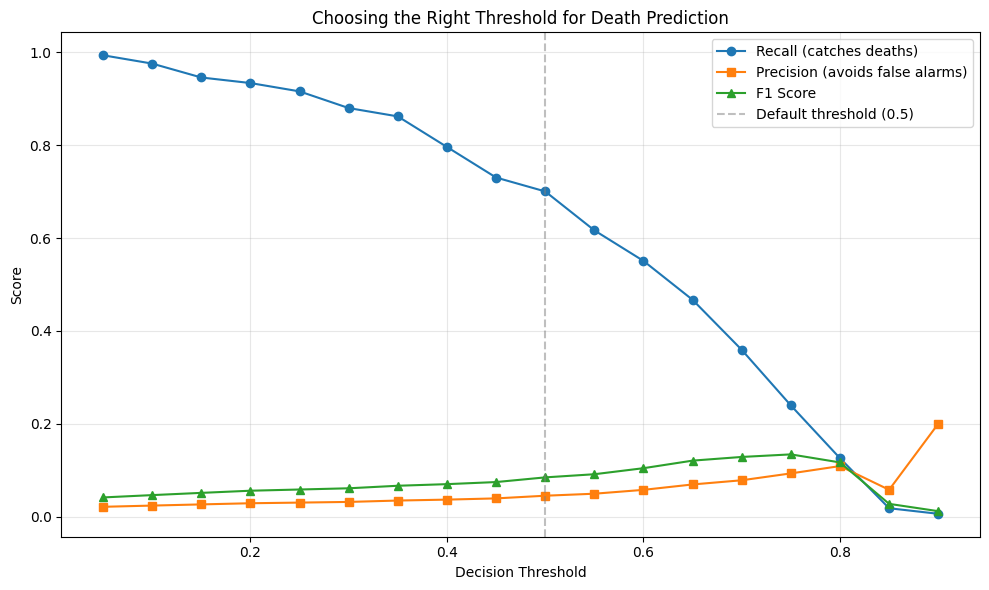


📌 BEST THRESHOLD BY F1: 0.75
   Recall:    0.240
   Precision: 0.093

   ⚕️ CLINICAL NOTE: In healthcare triage, missing a death (false negative)
   is usually far worse than a false alarm (false positive). Consider
   choosing a LOWER threshold than the F1-optimal one, prioritizing recall.


In [ ]:
# Use the class-weighted model's probabilities (proba_w from Technique 1)
thresholds = np.arange(0.05, 0.95, 0.05)
threshold_results = []

for t in thresholds:
    preds_t = (proba_w >= t).astype(int)
    threshold_results.append({
        'threshold': round(t, 2),
        'recall':    recall_score(y_test, preds_t),
        'precision': precision_score(y_test, preds_t, zero_division=0),
        'f1':        f1_score(y_test, preds_t, zero_division=0)
    })

thresh_df = pd.DataFrame(threshold_results)
print(thresh_df.to_string(index=False))

# Plot precision/recall/F1 vs threshold
plt.figure(figsize=(10, 6))
plt.plot(thresh_df['threshold'], thresh_df['recall'],    marker='o', label='Recall (catches deaths)')
plt.plot(thresh_df['threshold'], thresh_df['precision'], marker='s', label='Precision (avoids false alarms)')
plt.plot(thresh_df['threshold'], thresh_df['f1'],        marker='^', label='F1 Score')
plt.axvline(0.5, color='gray', linestyle='--', alpha=0.5, label='Default threshold (0.5)')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('Choosing the Right Threshold for Death Prediction')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Pick the threshold that maximizes F1 (or set your own clinical priority)
best_row = thresh_df.loc[thresh_df['f1'].idxmax()]
print(f"\n📌 BEST THRESHOLD BY F1: {best_row['threshold']:.2f}")
print(f"   Recall:    {best_row['recall']:.3f}")
print(f"   Precision: {best_row['precision']:.3f}")
print(f"\n   ⚕️ CLINICAL NOTE: In healthcare triage, missing a death (false negative)")
print(f"   is usually far worse than a false alarm (false positive). Consider")
print(f"   choosing a LOWER threshold than the F1-optimal one, prioritizing recall.")

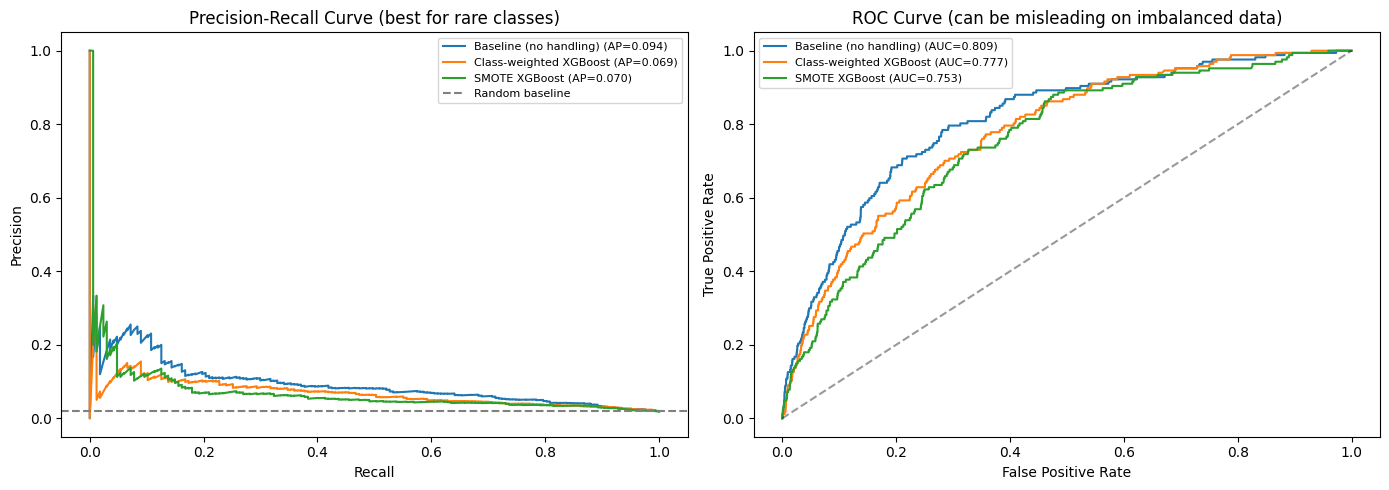

📌 WHY PR-AUC > ROC-AUC HERE:
   With 1.9% deaths, ROC-AUC can look high even with weak precision,
   because the False Positive Rate denominator (survivors) is huge.
   PR-AUC focuses on the minority class directly — use it as your main score.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, proba in [
    ('Baseline (no handling)', baseline_model.predict_proba(X_test)[:,1]),
    ('Class-weighted XGBoost', proba_w),
    ('SMOTE XGBoost',          proba_smote),
]:
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    axes[0].plot(rec, prec, label=f'{name} (AP={ap:.3f})')

    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[1].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

axes[0].axhline((y_test==1).mean(), color='gray', linestyle='--', label='Random baseline')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve (best for rare classes)')
axes[0].legend(fontsize=8)

axes[1].plot([0,1],[0,1],'k--', alpha=0.4)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve (can be misleading on imbalanced data)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print('📌 WHY PR-AUC > ROC-AUC HERE:')
print('   With 1.9% deaths, ROC-AUC can look high even with weak precision,')
print('   because the False Positive Rate denominator (survivors) is huge.')
print('   PR-AUC focuses on the minority class directly — use it as your main score.')

                Method  Recall (catches deaths)  Precision  F1 Score  PR-AUC  ROC-AUC
Baseline (no handling)                   0.0120     0.2222    0.0227  0.0938   0.8094
       Class Weighting                   0.7186     0.0415    0.0785  0.0691   0.7770
                 SMOTE                   0.4192     0.0528    0.0937  0.0699   0.7533


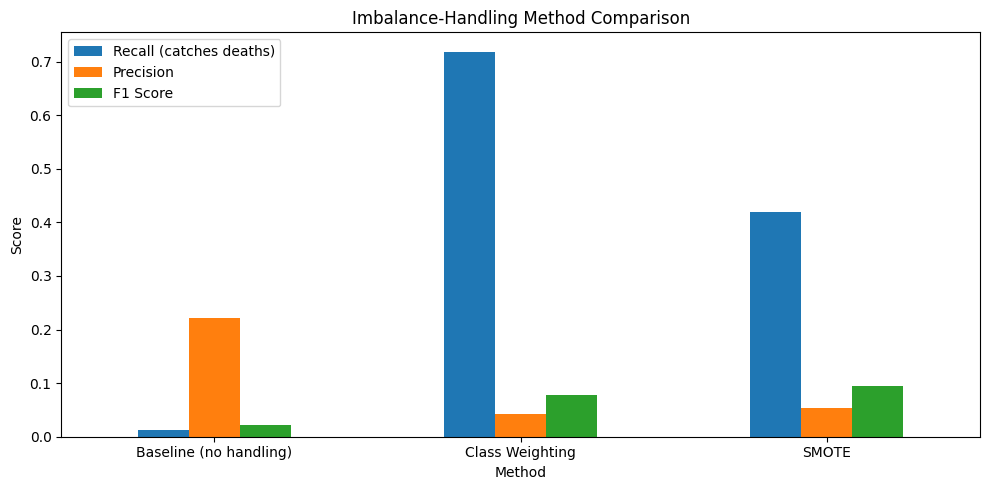


📌 TAKEAWAY: Recall on the baseline model is near zero — the model is
   blind to deaths. Class weighting and SMOTE both dramatically improve
   recall, usually at some cost to precision. Pick based on your priority:
   in cholera triage, catching deaths (high recall) is usually worth
   more false alarms.


In [ ]:
comparison = []
for name, preds, proba in [
    ('Baseline (no handling)', baseline_preds, baseline_model.predict_proba(X_test)[:,1]),
    ('Class Weighting',        preds_w,        proba_w),
    ('SMOTE',                  preds_smote,     proba_smote),
]:
    comparison.append({
        'Method': name,
        'Recall (catches deaths)': recall_score(y_test, preds),
        'Precision': precision_score(y_test, preds, zero_division=0),
        'F1 Score': f1_score(y_test, preds, zero_division=0),
        'PR-AUC': average_precision_score(y_test, proba),
        'ROC-AUC': roc_auc_score(y_test, proba),
    })

comp_df = pd.DataFrame(comparison)
print(comp_df.round(4).to_string(index=False))

comp_df.set_index('Method')[['Recall (catches deaths)','Precision','F1 Score']].plot(
    kind='bar', figsize=(10,5), rot=0
)
plt.title('Imbalance-Handling Method Comparison')
plt.ylabel('Score')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

print('\n📌 TAKEAWAY: Recall on the baseline model is near zero — the model is')
print('   blind to deaths. Class weighting and SMOTE both dramatically improve')
print('   recall, usually at some cost to precision. Pick based on your priority:')
print('   in cholera triage, catching deaths (high recall) is usually worth')
print('   more false alarms.')

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model_for_cv = xgb.XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    random_state=42, eval_metric='logloss', verbosity=0
)

cv_recall = cross_val_score(model_for_cv, X, y_encod, cv=skf, scoring='recall')
cv_prauc  = cross_val_score(model_for_cv, X, y_encod, cv=skf, scoring='average_precision')

print(f'5-Fold Stratified CV — Class-weighted XGBoost')
print(f'  Recall : {cv_recall.mean():.4f} ± {cv_recall.std():.4f}')
print(f'  PR-AUC : {cv_prauc.mean():.4f} ± {cv_prauc.std():.4f}')
print(f'\n  Per-fold recall: {np.round(cv_recall, 4)}')

5-Fold Stratified CV — Class-weighted XGBoost
  Recall : 0.6973 ± 0.0488
  PR-AUC : 0.0745 ± 0.0056

  Per-fold recall: [0.7857 0.6946 0.7006 0.6587 0.6467]


In [ ]:
# Choose whichever performed best in your comparison table above
# Here we save the class-weighted model with a tuned threshold

FINAL_THRESHOLD = best_row['threshold']  # from Technique 3

joblib.dump(xgb_weighted,    'cholera_imbalanced_model.pkl')
joblib.dump(FINAL_THRESHOLD, 'cholera_decision_threshold.pkl')
joblib.dump(y_encod,       'cholera_target_encoder.pkl')
joblib.dump(encodertarget,       'cholera_target_encoder.pkl')
joblib.dump(FEATURES,        'cholera_features.pkl')

print(f'✅ Model saved: cholera_imbalanced_model.pkl')
print(f'✅ Decision threshold saved: {FINAL_THRESHOLD:.2f}')
print(f'\nTo use this model on new data:')
print(f"""
  model     = joblib.load('cholera_imbalanced_model.pkl')
  threshold = joblib.load('cholera_decision_threshold.pkl')

  proba = model.predict_proba(new_X)[:, 1]
  predictions = (proba >= threshold).astype(int)  # NOT model.predict()!
""")


✅ Model saved: cholera_imbalanced_model.pkl
✅ Decision threshold saved: 0.75

To use this model on new data:

  model     = joblib.load('cholera_imbalanced_model.pkl')
  threshold = joblib.load('cholera_decision_threshold.pkl')

  proba = model.predict_proba(new_X)[:, 1]
  predictions = (proba >= threshold).astype(int)  # NOT model.predict()!



<Figure size 600x500 with 0 Axes>

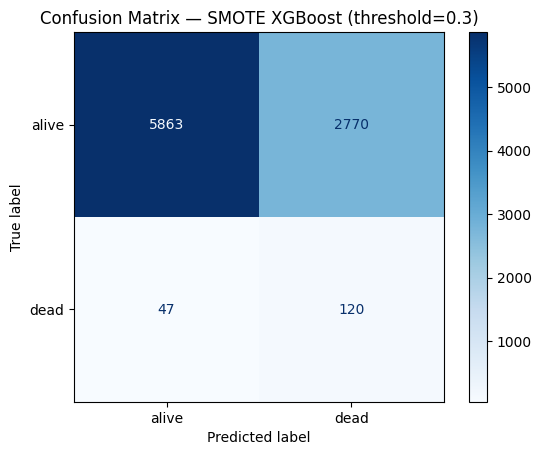


Confusion Matrix breakdown:
True Negatives  (correctly predicted Alive): 5863
False Positives (predicted Death, was Alive): 2770
False Negatives (predicted Alive, was Death): 47  ← this is what recall fixes
True Positives  (correctly predicted Death):  120


In [ ]:
threshold = 0.3
preds_w = (proba_smote >= threshold).astype(int)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, preds_w)
plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=encodertarget.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix — SMOTE XGBoost (threshold=0.3)')
plt.show()

print("\nConfusion Matrix breakdown:")
print(f"True Negatives  (correctly predicted Alive): {cm[0,0]}")
print(f"False Positives (predicted Death, was Alive): {cm[0,1]}")
print(f"False Negatives (predicted Alive, was Death): {cm[1,0]}  ← this is what recall fixes")
print(f"True Positives  (correctly predicted Death):  {cm[1,1]}")

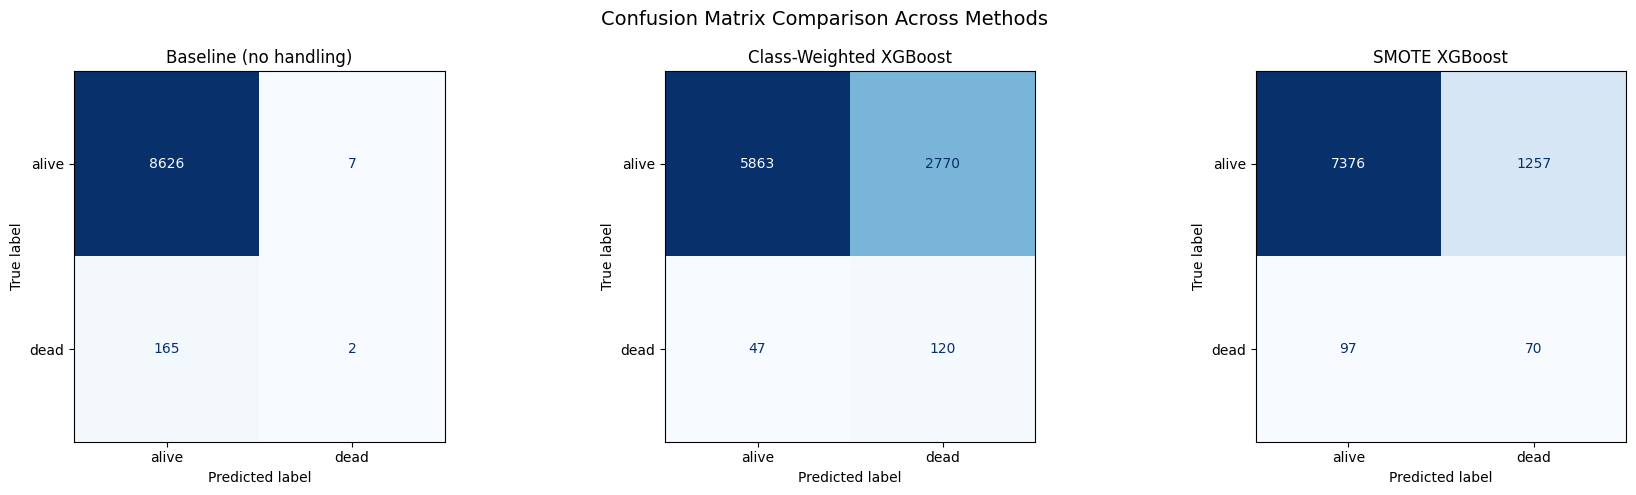




Baseline (no handling)
  True Negatives  (correctly predicted Alive): 8626
  False Positives (predicted Death, was Alive): 7
  False Negatives (predicted Alive, was Death): 165  ← missed deaths
  True Positives  (correctly predicted Death):  2

Class-Weighted XGBoost
  True Negatives  (correctly predicted Alive): 5863
  False Positives (predicted Death, was Alive): 2770
  False Negatives (predicted Alive, was Death): 47  ← missed deaths
  True Positives  (correctly predicted Death):  120

SMOTE XGBoost
  True Negatives  (correctly predicted Alive): 7376
  False Positives (predicted Death, was Alive): 1257
  False Negatives (predicted Alive, was Death): 97  ← missed deaths
  True Positives  (correctly predicted Death):  70


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_to_check = [
    ('Baseline (no handling)', baseline_preds),
    ('Class-Weighted XGBoost', preds_w),
    ('SMOTE XGBoost',          preds_smote),
]

for ax, (name, preds) in zip(axes, models_to_check):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=encodertarget.classes_)
    disp.plot(cmap='Blues', values_format='d', ax=ax, colorbar=False)
    ax.set_title(name)

plt.suptitle('Confusion Matrix Comparison Across Methods', fontsize=14)
plt.tight_layout()
plt.show()

# Print breakdown for each model
print("\n" + ""*60)
for name, preds in models_to_check:
    cm = confusion_matrix(y_test, preds)
    print(f"\n{name}")
    print(f"  True Negatives  (correctly predicted Alive): {cm[0,0]}")
    print(f"  False Positives (predicted Death, was Alive): {cm[0,1]}")
    print(f"  False Negatives (predicted Alive, was Death): {cm[1,0]}  ← missed deaths")
    print(f"  True Positives  (correctly predicted Death):  {cm[1,1]}")

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipe = make_pipeline(SimpleImputer(strategy="mean"),StandardScaler(),LogisticRegression())

In [ ]:
import numpy as np

np.isnan(X).sum()

,0
state,0
epiweek,0
season,0
setting,0
healthfac_type,0
geo,0
sex,0
age,0
heathfac_presn,0
sample_tak,0
